# Thesis EDA: Coveo Fashion E-Commerce Dataset
**Jatin Lather | GH1035176 | MSc AI, Data Science and Digital Business**

**Dataset:** `release_10_23_2020.csv` from the Coveo Shopper Intent Prediction release (Requena et al., 2020)




## Step 1: Mount Google Drive

Storing CSV on Google Drive so it persists across Colab sessions. Uploading `release_10_23_2020.csv` to a folder called `thesis_data` in Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/thesis_data/release_10_23_2020.csv'


Mounted at /content/drive


## Step 2: Installing and Importing Libraries

In [ ]:
import pandas as pd # pandas is used for data manipulation and cleaning.
import numpy as np # numpy is used to help in handling missing values and numerical operations.(creating arrays)
import matplotlib.pyplot as plt #used for plotting graphs
import seaborn as sns # used for creating visualizations

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded.')

Libraries loaded.


## Step 3: Loading the Data

The file is large (~500MB+), so we first peek at the first 5 rows before loading everything, just to confirm the column names and structure.

In [ ]:
# Previewing the first 5 rows without loading the whole file
preview = pd.read_csv(DATA_PATH, nrows=5)
print('Column names:')
print(preview.columns.tolist())
print()
print('First 5 rows:')
preview

Column names:
['session_id_hash', 'event_type', 'product_action', 'product_skus_hash', 'server_timestamp_epoch_ms', 'hashed_url']

First 5 rows:


,session_id_hash,event_type,product_action,product_skus_hash,server_timestamp_epoch_ms,hashed_url
0,00000005c19449b57d8d05dfc8b5474be0654032,pageview,NaN,NaN,1544469996111,da99729886aff70a02733b6cd69ee7df35622d9302347e...
1,00006a0ada94a5186163a25e9ed9c94481c820d9,pageview,NaN,NaN,1545737959865,e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9abf...
2,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908835402,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...
3,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908847263,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...
4,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,detail,90add4dd072e160034e98ddea257e0b59441eae00d8955...,1544909035879,8fa1ecf31ececb27ebe9c529966f3d1f907542fe138d5d...


In [ ]:
#loading the full file
print('Loading full dataset...')
df = pd.read_csv(DATA_PATH)
print(f'Done. Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loading full dataset...
Done. Shape: 5,433,611 rows x 6 columns


## Step 4: Basic Inspection

Before doing anything else, we need to understand what columns exist, what data types they are, and whether there are missing values.

In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5433611 entries, 0 to 5433610
Data columns (total 6 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   session_id_hash            object
 1   event_type                 object
 2   product_action             object
 3   product_skus_hash          object
 4   server_timestamp_epoch_ms  int64 
 5   hashed_url                 object
dtypes: int64(1), object(5)
memory usage: 248.7+ MB


In [ ]:
# Checking for missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values per column:')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('No missing values found.')

Missing values per column:
                   Missing Count  Missing %
product_action           2918789      53.72
product_skus_hash        3547557      65.29


In [ ]:
# How many unique sessions are there?
# The session column may be called 'session_id', 'SessionId', or similar
# Adjust column name below if needed after checking Step 3 output

# Auto-detect the session column
session_col = [c for c in df.columns if 'session' in c.lower()]
event_col   = [c for c in df.columns if 'event' in c.lower()]
action_col  = [c for c in df.columns if 'action' in c.lower()]
time_col    = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()]

print('Likely session column(s):', session_col)
print('Likely event column(s)  :', event_col)
print('Likely action column(s) :', action_col)
print('Likely time column(s)   :', time_col)

Likely session column(s): ['session_id_hash']
Likely event column(s)  : ['event_type']
Likely action column(s) : ['product_action']
Likely time column(s)   : ['server_timestamp_epoch_ms']


In [ ]:

SESSION_COL = session_col[0] if session_col else 'session_id'
ACTION_COL  = action_col[0]  if action_col  else 'product_action'
TIME_COL    = time_col[0]    if time_col    else 'server_timestamp_epoch_ms'

print(f'Using: SESSION_COL="{SESSION_COL}", ACTION_COL="{ACTION_COL}", TIME_COL="{TIME_COL}"')

n_sessions = df[SESSION_COL].nunique()
n_events   = len(df)
print(f'\nTotal events   : {n_events:,}')
print(f'Unique sessions: {n_sessions:,}')
print(f'Avg events/session: {n_events/n_sessions:.1f}')

Using: SESSION_COL="session_id_hash", ACTION_COL="product_action", TIME_COL="server_timestamp_epoch_ms"

Total events   : 5,433,611
Unique sessions: 443,660
Avg events/session: 12.2


## Step 5: Understanding the Event Taxonomy

The Coveo dataset encodes behaviour as a sequence of events. We need to understand exactly what event/action types exist before building labels and features.

In [ ]:
# What unique values exist in the action column?
print(f'Unique values in "{ACTION_COL}":')
action_counts = df[ACTION_COL].value_counts(dropna=False)
print(action_counts)


Unique values in "product_action":
product_action
NaN         2918789
detail      1640190
add          743363
click         69831
remove        51512
purchase       9926
Name: count, dtype: int64


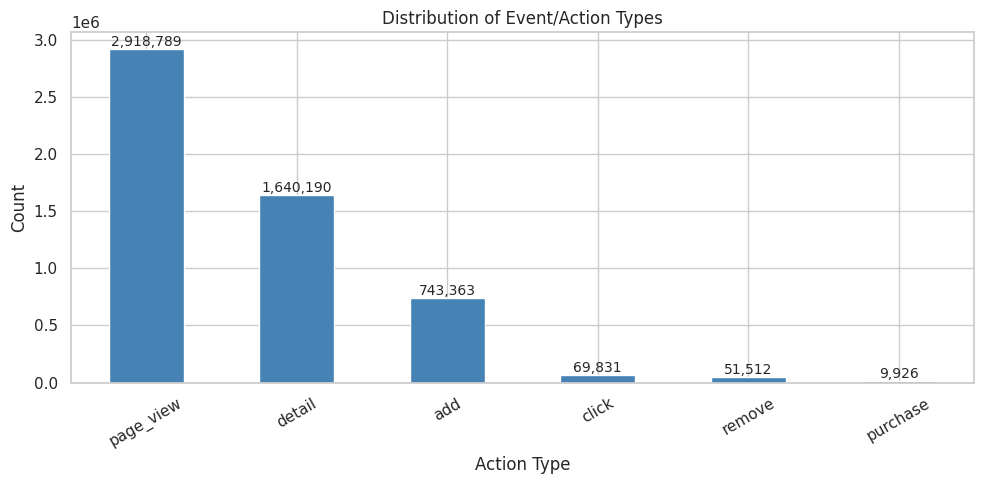

Figure saved to Drive.


In [ ]:
# Visualise event distribution
fig, ax = plt.subplots()
action_counts_clean = df[ACTION_COL].fillna('page_view').value_counts()
action_counts_clean.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Event/Action Types')
ax.set_xlabel('Action Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_data/fig_event_distribution.png', dpi=150)
plt.show()
print('Figure saved to Drive.')

## Step 6: Build Session-Level Labels

This is the core labelling step. For each session, we ask: did this session contain a purchase event?
- Sessions with at least one purchase action → label = 1 (buyer)
- All other sessions → label = 0 (non-buyer)

This creates the binary classification target for the thesis.

In [ ]:
# Identify the exact string used for purchase events
# Based on the paper, it is likely 'purchase' — confirm from Step 5 output
PURCHASE_ACTION = 'purchase'

# For each session, check if any event is a purchase
purchase_sessions = df[df[ACTION_COL] == PURCHASE_ACTION][SESSION_COL].unique()
purchase_set = set(purchase_sessions)

print(f'Sessions with at least one purchase event: {len(purchase_set):,}')
print(f'Total unique sessions: {n_sessions:,}')
print(f'Purchase session rate: {len(purchase_set)/n_sessions*100:.2f}%')

Sessions with at least one purchase event: 9,232
Total unique sessions: 443,660
Purchase session rate: 2.08%


Session-level class distribution:
purchased
0    434428
1      9232
Name: count, dtype: int64

Class balance: 2.1% purchase | 97.9% non-purchase


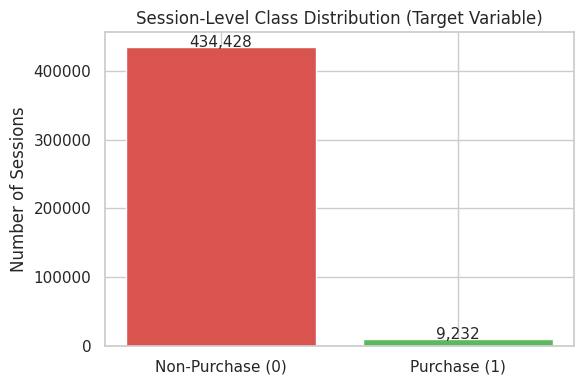

In [ ]:
# Add the label to the raw dataframe
df['purchased'] = df[SESSION_COL].isin(purchase_set).astype(int)

# Visualise class distribution
label_counts = df.groupby(SESSION_COL)['purchased'].max().value_counts()
print('Session-level class distribution:')
print(label_counts)
print(f'\nClass balance: {label_counts[1]/label_counts.sum()*100:.1f}% purchase | {label_counts[0]/label_counts.sum()*100:.1f}% non-purchase')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Non-Purchase (0)', 'Purchase (1)'], [label_counts[0], label_counts[1]],
       color=['#d9534f', '#5cb85c'], edgecolor='white')
ax.set_title('Session-Level Class Distribution (Target Variable)')
ax.set_ylabel('Number of Sessions')
for bar, val in zip(ax.patches, [label_counts[0], label_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_data/fig_class_distribution.png', dpi=150)
plt.show()

## Step 7: Engineer Session-Level Features

We now aggregate the event-level data into one row per session, computing the behavioural features described in the thesis proposal. These features become the input to the ML models.



n_events- Total number of events in the session

n_detail-Number of product detail views

n_add -Number of add-to-cart events

n_remove - Number of remove-from-cart events

n_purchase - Number of purchase events (used for labelling only)

add_to_view_ratio - n_add / n_detail (0 if no detail views)

has_remove - Binary: did the session contain any remove-from-cart?

session_duration_ms - Time from first to last event (milliseconds)

purchased - Target label: 1 if session ended in purchase, else 0

In [ ]:
# Define the action labels used in the dataset
# Adjust these strings if Step 5 showed different values
DETAIL_ACTION   = 'detail'
ADD_ACTION      = 'add'
REMOVE_ACTION   = 'remove'
PURCHASE_ACTION = 'purchase'

# Aggregate to session level
print('Building session-level feature matrix...')

sessions = df.groupby(SESSION_COL).agg(
    n_events       = (ACTION_COL, 'count'),
    n_detail       = (ACTION_COL, lambda x: (x == DETAIL_ACTION).sum()),
    n_add          = (ACTION_COL, lambda x: (x == ADD_ACTION).sum()),
    n_remove       = (ACTION_COL, lambda x: (x == REMOVE_ACTION).sum()),
    n_purchase     = (ACTION_COL, lambda x: (x == PURCHASE_ACTION).sum()),
    session_start  = (TIME_COL,   'min'),
    session_end    = (TIME_COL,   'max'),
    purchased      = ('purchased', 'max')
).reset_index()

# Derived features
sessions['add_to_view_ratio'] = sessions.apply(
    lambda r: r['n_add'] / r['n_detail'] if r['n_detail'] > 0 else 0, axis=1
)
sessions['has_remove'] = (sessions['n_remove'] > 0).astype(int)
sessions['session_duration_ms'] = sessions['session_end'] - sessions['session_start']

# Drop intermediate columns not needed for modelling
sessions.drop(columns=['session_start', 'session_end', 'n_purchase'], inplace=True)

print(f'Session-level dataset shape: {sessions.shape}')
sessions.head()

Building session-level feature matrix...
Session-level dataset shape: (443660, 9)


,session_id_hash,n_events,n_detail,n_add,n_remove,purchased,add_to_view_ratio,has_remove,session_duration_ms
0,00000005c19449b57d8d05dfc8b5474be0654032,0,0,0,0,0,0.0,0,0
1,00006a0ada94a5186163a25e9ed9c94481c820d9,0,0,0,0,0,0.0,0,0
2,00007d15aeb741b3cdd873cb3933351d699cc320,3,3,0,0,0,0.0,0,499332
3,0000c49d1359c87f112285d63a9fc0d4c50f73b4,0,0,0,0,0,0.0,0,253383
4,0001135282dbaf0e734345212ea6f8da9f5b66ed,0,0,0,0,0,0.0,0,0


In [ ]:
# Summary statistics for the feature matrix
sessions.describe().round(2)

,n_events,n_detail,n_add,n_remove,purchased,add_to_view_ratio,has_remove,session_duration_ms
count,443660.00,443660.0,443660.00,443660.00,443660.00,443660.00,443660.00,443660.00
mean,5.67,3.7,1.68,0.12,0.02,0.28,0.04,573327.36
std,35.90,8.1,33.73,0.98,0.14,9.11,0.19,1122276.84
min,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,1.0,0.00,0.00,0.00,0.00,0.00,114523.00
75%,4.00,4.0,0.00,0.00,0.00,0.00,0.00,655026.75
max,7432.00,457.0,7349.00,94.00,1.00,3570.00,1.00,59985656.00


## Step 8: Exploratory Feature Analysis

Now we visualise each feature, split by class (purchase vs non-purchase), to get an initial sense of which features separate the two groups. This directly informs the Feature Importance section of the thesis.

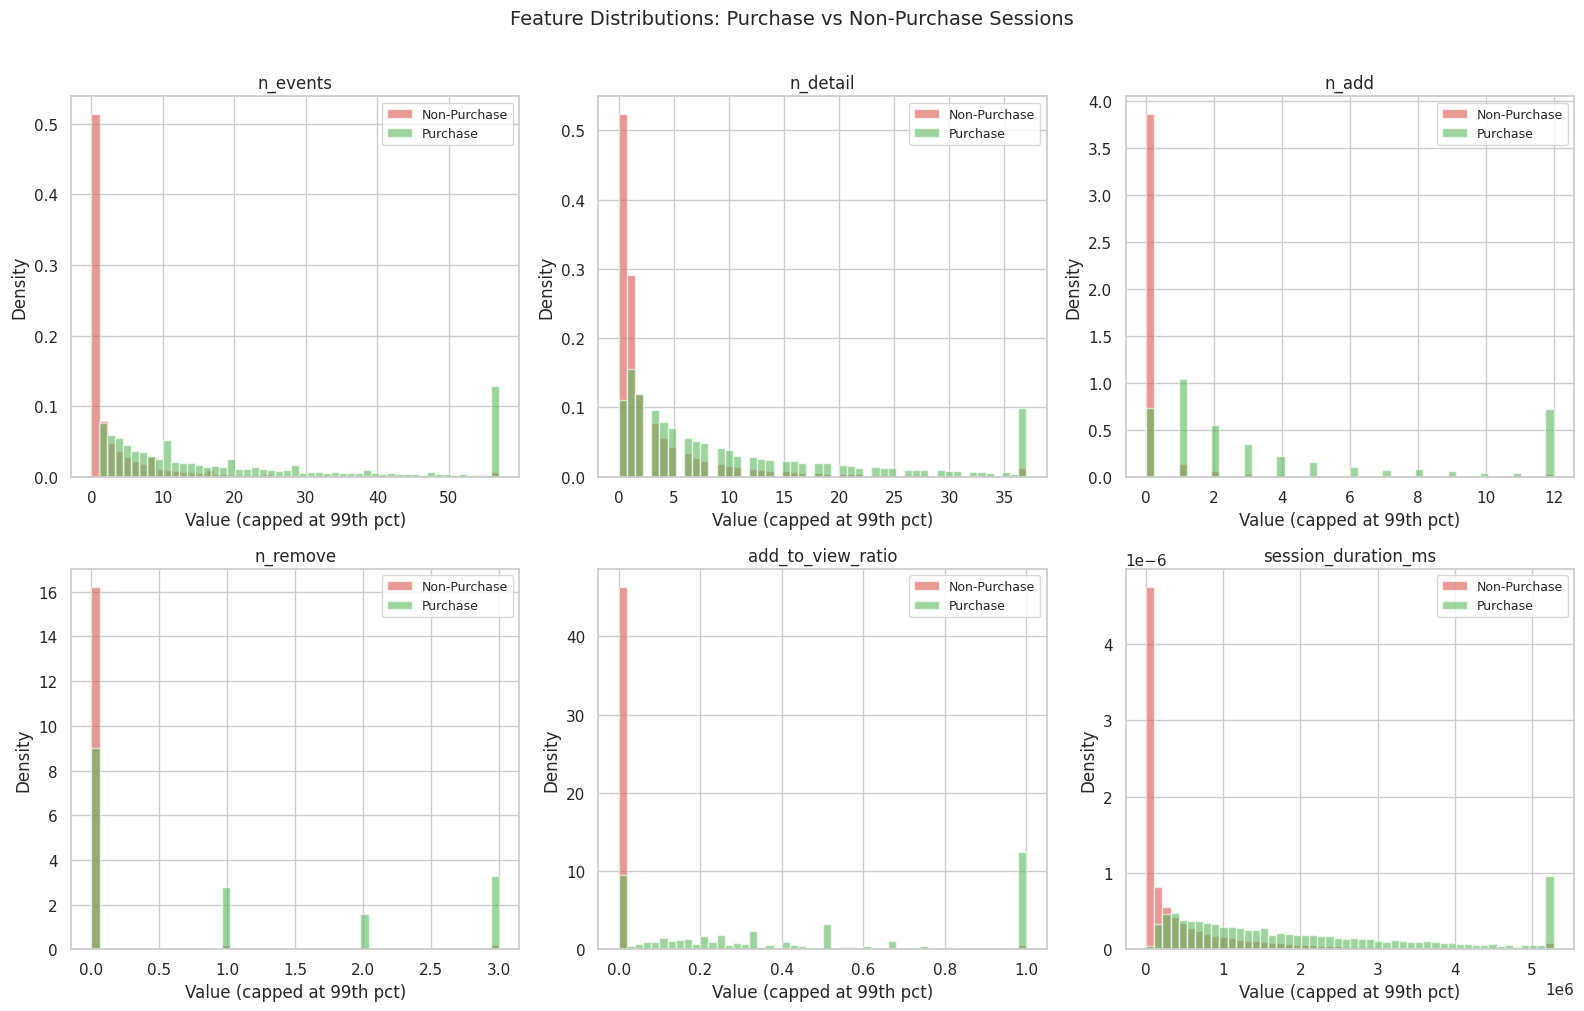

Figure saved.


In [ ]:
# Compare distributions of numeric features by class
features_to_plot = ['n_events', 'n_detail', 'n_add', 'n_remove',
                    'add_to_view_ratio', 'session_duration_ms']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

buyers     = sessions[sessions['purchased'] == 1]
non_buyers = sessions[sessions['purchased'] == 0]

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    # Cap at 99th percentile for readability
    cap = sessions[feat].quantile(0.99)
    ax.hist(non_buyers[feat].clip(upper=cap), bins=50, alpha=0.6,
            label='Non-Purchase', color='#d9534f', density=True)
    ax.hist(buyers[feat].clip(upper=cap),     bins=50, alpha=0.6,
            label='Purchase',     color='#5cb85c', density=True)
    ax.set_title(feat)
    ax.set_xlabel('Value (capped at 99th pct)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions: Purchase vs Non-Purchase Sessions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_data/fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [ ]:
# Mean feature values by class — useful table for the thesis Results section
mean_by_class = sessions.groupby('purchased')[features_to_plot + ['has_remove']].mean().round(4)
mean_by_class.index = ['Non-Purchase', 'Purchase']
print('Mean feature values by class:')
mean_by_class

Mean feature values by class:


,n_events,n_detail,n_add,n_remove,add_to_view_ratio,session_duration_ms,has_remove
Non-Purchase,4.8174,3.5109,1.0889,0.0838,0.2091,5.362416e+05,0.0269
Purchase,45.7097,12.4515,29.2782,1.6356,3.5533,2.318465e+06,0.4591


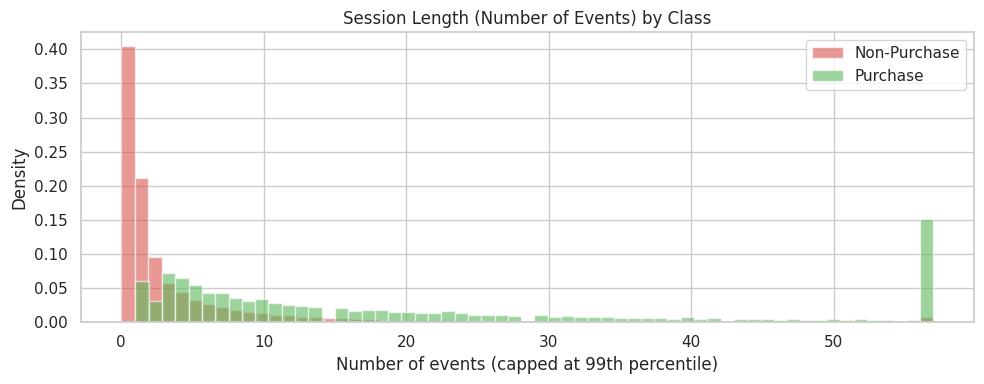

In [ ]:
# Session length distribution
fig, ax = plt.subplots(figsize=(10, 4))
cap = sessions['n_events'].quantile(0.99)
ax.hist(sessions[sessions['purchased']==0]['n_events'].clip(upper=cap),
        bins=60, alpha=0.6, label='Non-Purchase', color='#d9534f', density=True)
ax.hist(sessions[sessions['purchased']==1]['n_events'].clip(upper=cap),
        bins=60, alpha=0.6, label='Purchase',     color='#5cb85c', density=True)
ax.set_title('Session Length (Number of Events) by Class')
ax.set_xlabel('Number of events (capped at 99th percentile)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_data/fig_session_length.png', dpi=150)
plt.show()

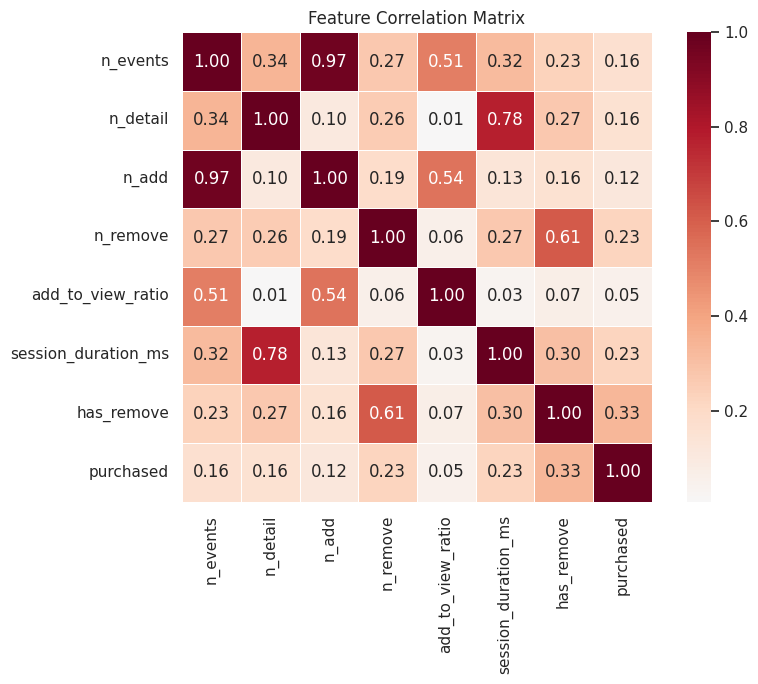

Higher correlation with "purchased" = stronger predictor candidate.


In [ ]:
# Correlation heatmap of features
fig, ax = plt.subplots(figsize=(9, 7))
corr_cols = features_to_plot + ['has_remove', 'purchased']
corr = sessions[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_data/fig_correlation_matrix.png', dpi=150)
plt.show()
print('Higher correlation with "purchased" = stronger predictor candidate.')

## Step 9: Key EDA Findings Summary


In [ ]:
total_sessions   = len(sessions)
n_buyers         = sessions['purchased'].sum()
n_non_buyers     = total_sessions - n_buyers
purchase_rate    = n_buyers / total_sessions * 100
avg_events_buyer = buyers['n_events'].mean()
avg_events_non   = non_buyers['n_events'].mean()
avg_add_buyer    = buyers['n_add'].mean()
avg_add_non      = non_buyers['n_add'].mean()

print('=' * 55)
print('EDA SUMMARY — Coveo Fashion Dataset')
print('=' * 55)
print(f'Total events in file      : {len(df):,}')
print(f'Total unique sessions     : {total_sessions:,}')
print(f'Purchase sessions (label=1): {n_buyers:,} ({purchase_rate:.2f}%)')
print(f'Non-purchase sessions (0)  : {n_non_buyers:,} ({100-purchase_rate:.2f}%)')
print()
print('--- Avg feature values by class ---')
print(f'Avg events/session  — Buyers: {avg_events_buyer:.1f}  |  Non-buyers: {avg_events_non:.1f}')
print(f'Avg add-to-cart     — Buyers: {avg_add_buyer:.2f}  |  Non-buyers: {avg_add_non:.2f}')
print(f'Avg add:view ratio  — Buyers: {buyers["add_to_view_ratio"].mean():.3f}  |  Non-buyers: {non_buyers["add_to_view_ratio"].mean():.3f}')
print()
print('--- Class imbalance note ---')
print(f'Imbalance ratio: ~{n_non_buyers//n_buyers}:1 (non-purchase:purchase)')
print('Action required: Use class_weight="balanced" in all models.')
print('=' * 55)

EDA SUMMARY — Coveo Fashion Dataset
Total events in file      : 5,433,611
Total unique sessions     : 443,660
Purchase sessions (label=1): 9,232 (2.08%)
Non-purchase sessions (0)  : 434,428 (97.92%)

--- Avg feature values by class ---
Avg events/session  — Buyers: 45.7  |  Non-buyers: 4.8
Avg add-to-cart     — Buyers: 29.28  |  Non-buyers: 1.09
Avg add:view ratio  — Buyers: 3.553  |  Non-buyers: 0.209

--- Class imbalance note ---
Imbalance ratio: ~47:1 (non-purchase:purchase)
Action required: Use class_weight="balanced" in all models.


In [ ]:
SAVE_PATH = '/content/drive/MyDrive/thesis_data/sessions_features.csv'
sessions.to_csv(SAVE_PATH, index=False)
print(f'Session-level feature matrix saved to: {SAVE_PATH}')
print(f'Shape: {sessions.shape}')
print()
print('Columns saved:')
for col in sessions.columns:
    print(f'  - {col}')

Session-level feature matrix saved to: /content/drive/MyDrive/thesis_data/sessions_features.csv
Shape: (443660, 9)

Columns saved:
  - session_id_hash
  - n_events
  - n_detail
  - n_add
  - n_remove
  - purchased
  - add_to_view_ratio
  - has_remove
  - session_duration_ms


## Step 10: Installing Libraries

In [ ]:
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, RocCurveDisplay,
    average_precision_score, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

print('All libraries loaded.')
print(f'XGBoost version: {xgb.__version__}')
# Output folder for all saved figures
FIG_DIR = '/content/drive/MyDrive/thesis_data/'


All libraries loaded.
XGBoost version: 3.2.0


## Step 11: Preprocessing

In [ ]:
# ── Define features and target ────────────────────────────────────────────────
#
# These are the 7 features engineered in the EDA.
# session_id is an identifier only — we drop it from modelling.
#
FEATURE_COLS = [
    'n_events',            # total events in session
    'n_detail',            # product detail views
    'n_add',               # add-to-cart events
    'n_remove',            # remove-from-cart events
    'add_to_view_ratio',   # n_add / n_detail
    'has_remove',          # binary: any remove event?
    'session_duration_ms'  # total session length in milliseconds
]
TARGET_COL = 'purchased'

X = sessions[FEATURE_COLS]
y = sessions[TARGET_COL]

print(f'Features : {FEATURE_COLS}')
print(f'\nClass distribution:')
vc = y.value_counts()
print(f'  Non-purchase (0): {vc[0]:,}  ({vc[0]/len(y)*100:.1f}%)')
print(f'  Purchase     (1): {vc[1]:,}  ({vc[1]/len(y)*100:.1f}%)')
print(f'  Imbalance ratio : {vc[0]//vc[1]}:1')

Features : ['n_events', 'n_detail', 'n_add', 'n_remove', 'add_to_view_ratio', 'has_remove', 'session_duration_ms']

Class distribution:
  Non-purchase (0): 434,428  (97.9%)
  Purchase     (1): 9,232  (2.1%)
  Imbalance ratio : 47:1


In [ ]:
# ── Check for missing values ──────────────────────────────────────────────────
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values. Ready to split.')
else:
    print('Missing values found — filling with 0:')
    print(missing[missing > 0])
    X = X.fillna(0)

No missing values. Ready to split.


In [ ]:
# ── Train / Test split ────────────────────────────────────────────────────────
#
# 80% train, 20% test.
# stratify=y ensures the same class ratio in both splits.
#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} sessions')
print(f'Test set     : {X_test.shape[0]:,} sessions')
print(f'Train purchase rate: {y_train.mean()*100:.2f}%')
print(f'Test  purchase rate: {y_test.mean()*100:.2f}%')

Training set : 354,928 sessions
Test set     : 88,732 sessions
Train purchase rate: 2.08%
Test  purchase rate: 2.08%


In [ ]:
# ── Helper: unified evaluation function ──────────────────────────────────────
#
# Call this after fitting any model to get a consistent results dict
# and print a formatted report.
#
def evaluate(model_name, y_true, y_pred_proba, y_pred_class):
    auc   = roc_auc_score(y_true, y_pred_proba)
    ap    = average_precision_score(y_true, y_pred_proba)
    f1    = f1_score(y_true, y_pred_class)
    prec  = precision_score(y_true, y_pred_class)
    rec   = recall_score(y_true, y_pred_class)

    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')
    print(f'  AUC-ROC            : {auc:.4f}')
    print(f'  Average Precision  : {ap:.4f}')
    print(f'  F1-Score           : {f1:.4f}')
    print(f'  Precision          : {prec:.4f}')
    print(f'  Recall             : {rec:.4f}')
    print(f'{'='*50}')

    return {
        'Model': model_name,
        'AUC-ROC': round(auc, 4),
        'Avg Precision': round(ap, 4),
        'F1': round(f1, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4)
    }

# Store results from each model here
results_table = []

## Step 12: Logistic Regression
Logistic Regression is the interpretable baseline. We use class_weight=balanced to handle the class imbalance, and scale the features first since LR is sensitive to feature magnitude.


In [ ]:
# ── Train ─────────────────────────────────────────────────────────────────────
#
# Pipeline: StandardScaler → LogisticRegression
# class_weight='balanced' automatically adjusts weights inversely
# proportional to class frequencies.
#
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

lr_pipeline.fit(X_train, y_train)

lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred  = lr_pipeline.predict(X_test)

lr_results = evaluate('Logistic Regression', y_test, lr_proba, lr_pred)
results_table.append(lr_results)


  Logistic Regression
  AUC-ROC            : 0.9733
  Average Precision  : 0.2767
  F1-Score           : 0.3902
  Precision          : 0.2425
  Recall             : 0.9989


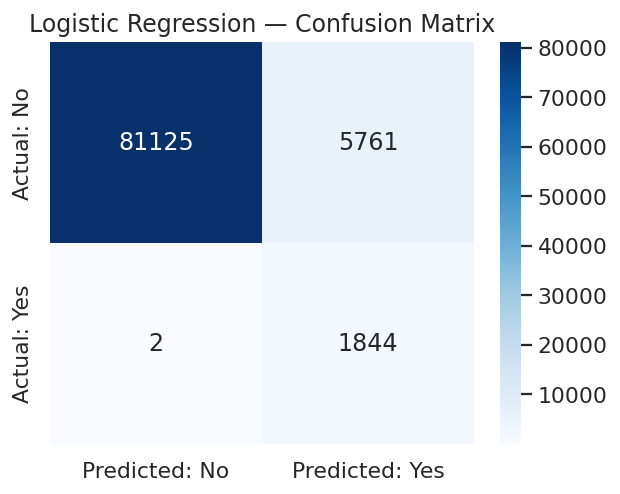

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_cm_lr.png', dpi=150)
plt.show()

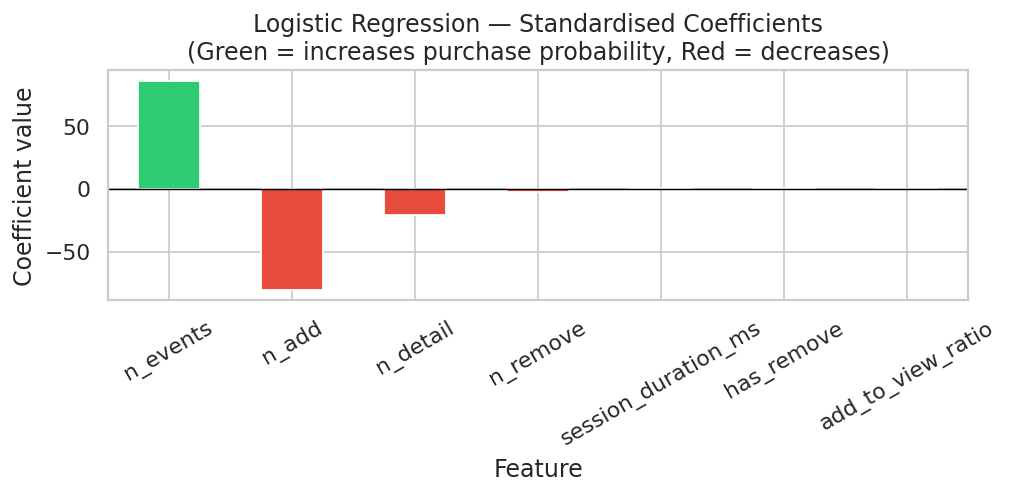


Coefficients (sorted by absolute magnitude):
n_events               86.325808
n_add                 -80.647744
n_detail              -20.634530
n_remove               -2.470619
session_duration_ms     0.661844
has_remove              0.393526
add_to_view_ratio       0.127523


In [ ]:
# ── Coefficients (feature importance for LR) ─────────────────────────────────
#
# In Logistic Regression, the magnitude of a standardised coefficient
# reflects how much that feature shifts the log-odds of purchase.
#
lr_coefs = pd.Series(
    lr_pipeline.named_steps['lr'].coef_[0],
    index=FEATURE_COLS
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in lr_coefs]
lr_coefs.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Standardised Coefficients\n(Green = increases purchase probability, Red = decreases)')
ax.set_ylabel('Coefficient value')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_coef_lr.png', dpi=150)
plt.show()

print('\nCoefficients (sorted by absolute magnitude):')
print(lr_coefs.to_string())

## Step 13: Random Forest
Random Forest is the ensemble baseline. No scaling needed — tree-based models are invariant to feature magnitude.

In [ ]:
# ── Train ─────────────────────────────────────────────────────────────────────
#
# n_estimators=300: enough trees for stable predictions without excessive runtime.
# class_weight='balanced_subsample': reweights within each bootstrap sample.
#
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1          # use all CPU cores
)

rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)

rf_results = evaluate('Random Forest', y_test, rf_proba, rf_pred)
results_table.append(rf_results)


  Random Forest
  AUC-ROC            : 0.9706
  Average Precision  : 0.6301
  F1-Score           : 0.5290
  Precision          : 0.6697
  Recall             : 0.4372


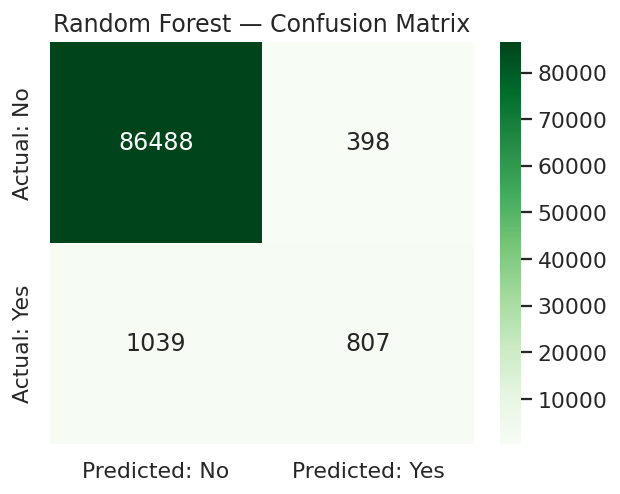

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_cm_rf.png', dpi=150)
plt.show()

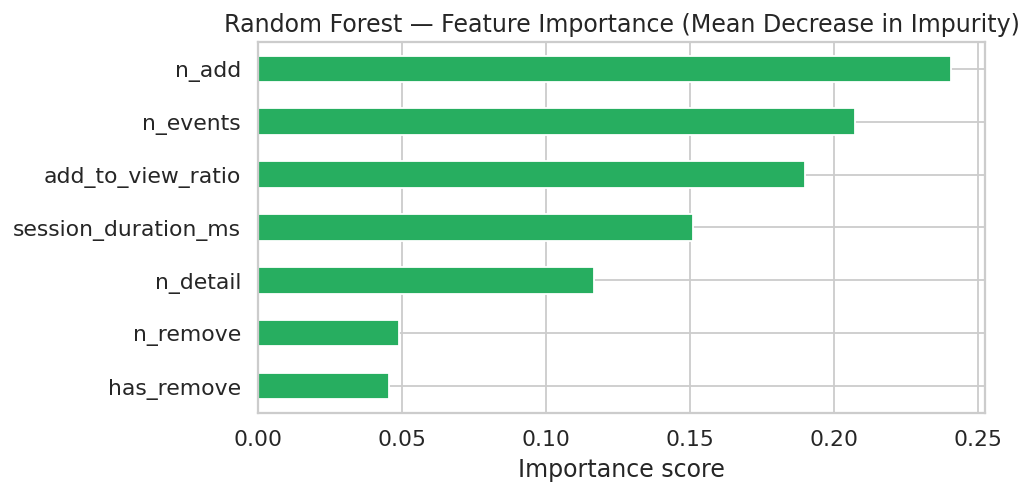


Feature importances (highest first):
n_add                  0.240539
n_events               0.207240
add_to_view_ratio      0.189847
session_duration_ms    0.151063
n_detail               0.116776
n_remove               0.048917
has_remove             0.045617


In [ ]:
# ── Feature Importance (Mean Decrease in Impurity) ───────────────────────────
rf_importances = pd.Series(
    rf.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
rf_importances.plot(kind='barh', ax=ax, color='#27ae60', edgecolor='white')
ax.set_title('Random Forest — Feature Importance (Mean Decrease in Impurity)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_importance_rf.png', dpi=150)
plt.show()

print('\nFeature importances (highest first):')
print(rf_importances.sort_values(ascending=False).to_string())

## Step 14: XGBoost
XGBoost is the primary model and the direct benchmark against Requena et al. (2020). The scale_pos_weight parameter handles class imbalance by upweighting the minority (purchase) class.


In [ ]:
# ── Compute scale_pos_weight ─────────────────────────────────────────────────
#
# XGBoost's recommended approach for imbalanced data:
# scale_pos_weight = count(negative class) / count(positive class)
#
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {neg_count:,} / {pos_count:,} = {spw:.2f}')

scale_pos_weight = 347,542 / 7,386 = 47.05


In [ ]:
# ── Train ─────────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

xgb_results = evaluate('XGBoost', y_test, xgb_proba, xgb_pred)
results_table.append(xgb_results)


  XGBoost
  AUC-ROC            : 0.9874
  Average Precision  : 0.6304
  F1-Score           : 0.4263
  Precision          : 0.2729
  Recall             : 0.9740


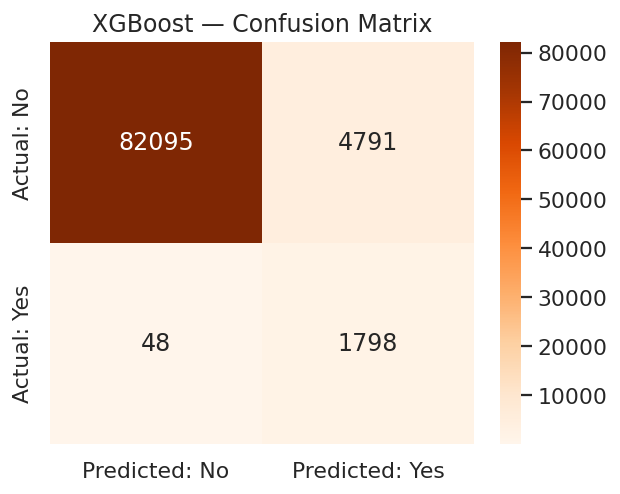

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_cm_xgb.png', dpi=150)
plt.show()

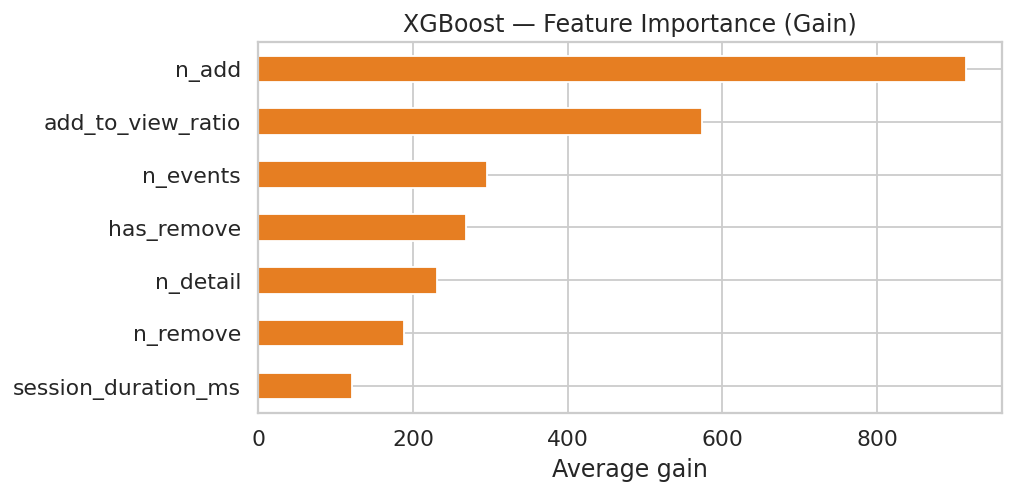


XGBoost feature importances by gain (highest first):
n_add                  915.066284
add_to_view_ratio      573.070679
n_events               295.401978
has_remove             268.138916
n_detail               231.686356
n_remove               188.802734
session_duration_ms    121.878410


In [ ]:
# ── Feature Importance (XGBoost gain) ────────────────────────────────────────
#
# 'gain' = average improvement in loss brought by a feature across all
# splits where it is used. This is the most informative importance metric.
#
xgb_importances = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain')
).reindex(FEATURE_COLS).fillna(0).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
xgb_importances.plot(kind='barh', ax=ax, color='#e67e22', edgecolor='white')
ax.set_title('XGBoost — Feature Importance (Gain)')
ax.set_xlabel('Average gain')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_importance_xgb.png', dpi=150)
plt.show()

print('\nXGBoost feature importances by gain (highest first):')
print(xgb_importances.sort_values(ascending=False).to_string())

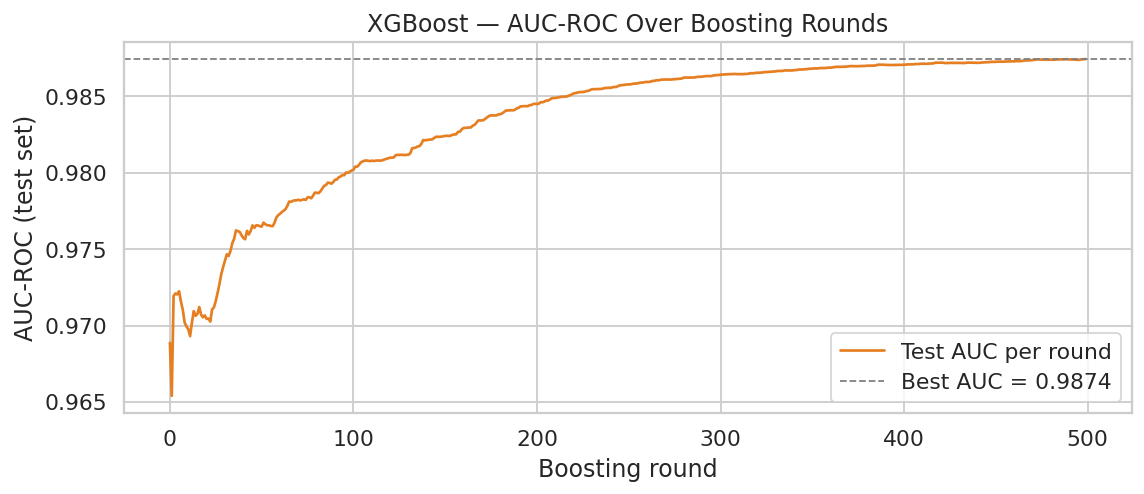

In [ ]:
# ── Training AUC curve (learning curve over boosting rounds) ─────────────────
#
# Shows that the model was not over-trained: test AUC should plateau,
# not decline after the peak.
#
evals_result = xgb_model.evals_result()
test_auc_curve = evals_result['validation_0']['auc']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(test_auc_curve, color='#e67e22', linewidth=1.5, label='Test AUC per round')
ax.axhline(max(test_auc_curve), linestyle='--', color='gray', linewidth=1,
           label=f'Best AUC = {max(test_auc_curve):.4f}')
ax.set_title('XGBoost — AUC-ROC Over Boosting Rounds')
ax.set_xlabel('Boosting round')
ax.set_ylabel('AUC-ROC (test set)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_xgb_learning_curve.png', dpi=150)
plt.show()

## Step 15: ROC curves - All Three Models Together
The combined ROC plot is the key comparative figure for the thesis results.

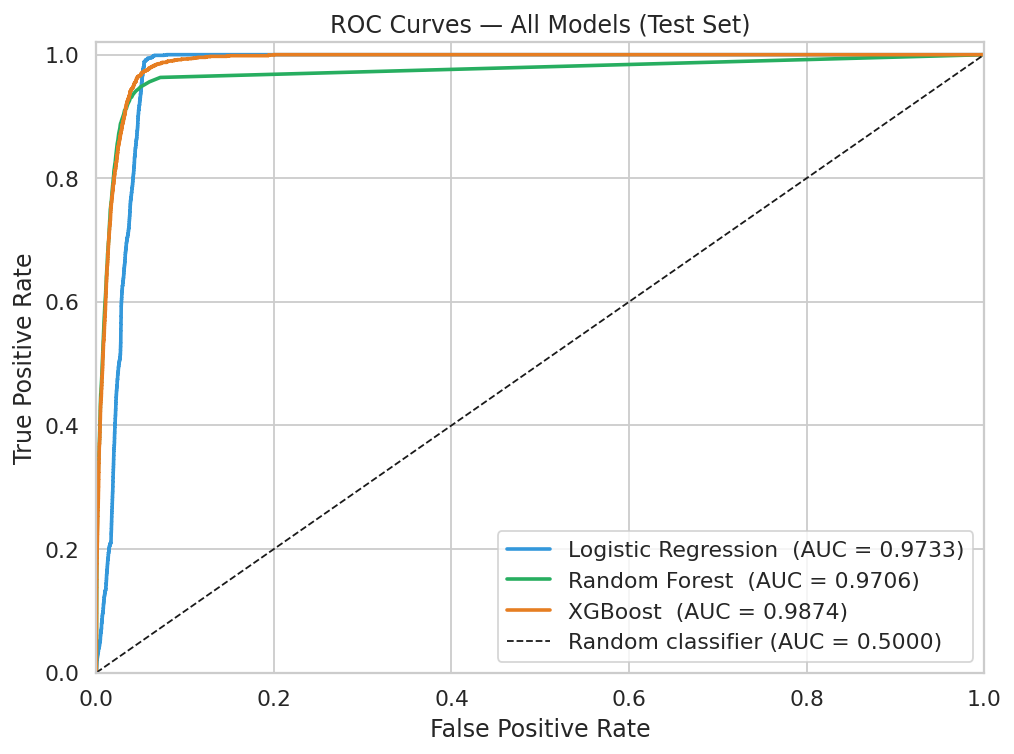

ROC curve saved.


In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

models_for_roc = [
    ('Logistic Regression', lr_proba,  '#3498db'),
    ('Random Forest',       rf_proba,  '#27ae60'),
    ('XGBoost',             xgb_proba, '#e67e22'),
]

for name, proba, colour in models_for_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=colour, linewidth=2,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (Test Set)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_roc_all_models.png', dpi=150)
plt.show()
print('ROC curve saved.')

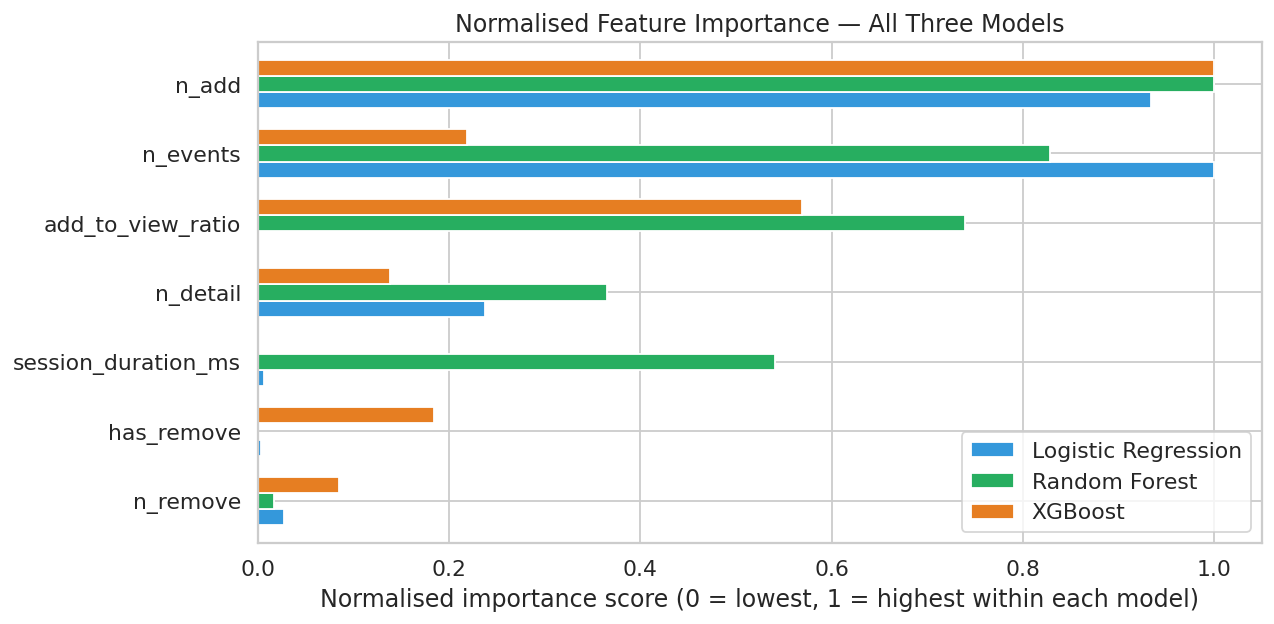

In [ ]:
# ── Combined feature importance comparison ────────────────────────────────────
#
# Shows which features each model considers important.
# Normalise each model's scores to [0, 1] for fair comparison.
#
def normalise(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s

# LR: use absolute coefficients
lr_imp = normalise(pd.Series(
    np.abs(lr_pipeline.named_steps['lr'].coef_[0]),
    index=FEATURE_COLS
))

# RF: mean decrease in impurity, already normalised
rf_imp = normalise(pd.Series(rf.feature_importances_, index=FEATURE_COLS))

# XGBoost: gain scores
xgb_raw = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain')
).reindex(FEATURE_COLS).fillna(0)
xgb_imp = normalise(xgb_raw)

importance_df = pd.DataFrame({
    'Logistic Regression': lr_imp,
    'Random Forest':       rf_imp,
    'XGBoost':             xgb_imp
})

# Sort by mean importance across models
importance_df['mean'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean', ascending=True).drop('mean', axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
importance_df.plot(kind='barh', ax=ax,
                   color=['#3498db', '#27ae60', '#e67e22'],
                   width=0.7, edgecolor='white')
ax.set_title('Normalised Feature Importance — All Three Models')
ax.set_xlabel('Normalised importance score (0 = lowest, 1 = highest within each model)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_importance_comparison.png', dpi=150)
plt.show()

## Step 16: Early Prediction Analysis
We reload the raw event-level data, artificially truncate each session to 25%, 50%, and 75% of its full length, re-engineer features from the truncated sequence, and evaluate the best model (XGBoost) at each truncation point.

In [ ]:
# ── Reload raw data for early prediction ──────────────────────────────────────
# Input: the original raw file (needed for early prediction analysis)
RAW_PATH = '/content/drive/MyDrive/thesis_data/release_10_23_2020.csv'
print('Loading raw event data for early prediction analysis...')
raw = pd.read_csv(RAW_PATH)

# Use the confirmed column names from the EDA
# The actual session ID column in the dataset is 'session_id_hash'
SESSION_COL = 'session_id_hash'
ACTION_COL  = 'product_action'
TIME_COL    = 'server_timestamp_epoch_ms'

# Sort events within each session by timestamp
raw = raw.sort_values([SESSION_COL, TIME_COL]).reset_index(drop=True)

# Add the label from our sessions dataframe
label_map = sessions.set_index(SESSION_COL)['purchased'].to_dict()
raw['purchased'] = raw[SESSION_COL].map(label_map)

# Keep only sessions that exist in our labelled set
raw = raw[raw['purchased'].notna()]
raw['purchased'] = raw['purchased'].astype(int)

print(f'Raw events loaded: {len(raw):,}')
print(f'Unique sessions  : {raw[SESSION_COL].nunique():,}')

Loading raw event data for early prediction analysis...
Raw events loaded: 5,433,611
Unique sessions  : 443,660


In [ ]:
# Feature engineering function

def engineer_features(df):
    agg = df.groupby(SESSION_COL).agg(
        n_events      = (ACTION_COL, 'count'),
        n_detail      = (ACTION_COL, lambda x: (x == 'detail').sum()),
        n_add         = (ACTION_COL, lambda x: (x == 'add').sum()),
        n_remove      = (ACTION_COL, lambda x: (x == 'remove').sum()),
        session_start = (TIME_COL,   'min'),
        session_end   = (TIME_COL,   'max'),
        purchased     = ('purchased', 'max')
    ).reset_index()

    agg['add_to_view_ratio'] = agg.apply(
        lambda r: r['n_add'] / r['n_detail'] if r['n_detail'] > 0 else 0, axis=1
    )
    agg['has_remove']          = (agg['n_remove'] > 0).astype(int)
    agg['session_duration_ms'] = agg['session_end'] - agg['session_start']
    agg.drop(columns=['session_start', 'session_end'], inplace=True)

    return agg

In [ ]:
# ── Truncation function ───────────────────────────────────────────────────────
#
# For each session, keep only the first `fraction` of its events.
# A session with 10 events at fraction=0.50 becomes 5 events.
# Sessions shorter than 2 events after truncation are dropped.
#
def truncate_sessions(df, fraction):
    def keep_first(group):
        n = max(1, int(len(group) * fraction))
        return group.head(n)
    truncated = df.groupby(SESSION_COL, group_keys=False).apply(keep_first)
    # Drop sessions that become too short to generate features
    valid = truncated.groupby(SESSION_COL).filter(lambda g: len(g) >= 2)
    return valid

In [ ]:
# ── Run early prediction at 25%, 50%, 75%, 100% ───────────────────────────────
#
# For each truncation point:
#   1. Truncate the raw events
#   2. Re-engineer features from the truncated sessions
#   3. Evaluate the pre-trained XGBoost model on those truncated features
#
# IMPORTANT: We use the XGBoost model trained on FULL sessions.
# This tests how well a full-session model degrades on partial data —
# the relevant scenario for real-time deployment.
#

# Get the session IDs in the test set
test_session_ids = sessions.iloc[X_test.index][SESSION_COL].values
test_session_set = set(test_session_ids)

fractions    = [0.25, 0.50, 0.75, 1.00]
early_results = []

for frac in fractions:
    label = f'{int(frac*100)}%'

    if frac == 1.00:
        # Full session — use the results already computed
        auc = roc_auc_score(y_test, xgb_proba)
        n   = len(y_test)
    else:
        # Truncate raw events
        trunc_raw = raw[raw[SESSION_COL].isin(test_session_set)]
        trunc_raw = truncate_sessions(trunc_raw, frac)

        # Re-engineer features
        trunc_feats = engineer_features(trunc_raw)
        trunc_feats = trunc_feats.fillna(0)

        # Align to sessions that survived truncation
        X_trunc = trunc_feats[FEATURE_COLS]
        y_trunc = trunc_feats['purchased']
        n = len(y_trunc)

        # Predict using the already-trained XGBoost
        proba_trunc = xgb_model.predict_proba(X_trunc)[:, 1]
        auc = roc_auc_score(y_trunc, proba_trunc)

    early_results.append({
        'Session completeness': label,
        'AUC-ROC': round(auc, 4),
        'Sessions evaluated': n
    })
    print(f'  {label} of session observed → AUC-ROC = {auc:.4f}  (n={n:,})')

early_df = pd.DataFrame(early_results)
print('\nEarly prediction results:')
print(early_df.to_string(index=False))

  25% of session observed → AUC-ROC = 0.7475  (n=31,112)
  50% of session observed → AUC-ROC = 0.8350  (n=46,241)
  75% of session observed → AUC-ROC = 0.8816  (n=52,765)
  100% of session observed → AUC-ROC = 0.9874  (n=88,732)

Early prediction results:
Session completeness  AUC-ROC  Sessions evaluated
                 25%   0.7475               31112
                 50%   0.8350               46241
                 75%   0.8816               52765
                100%   0.9874               88732


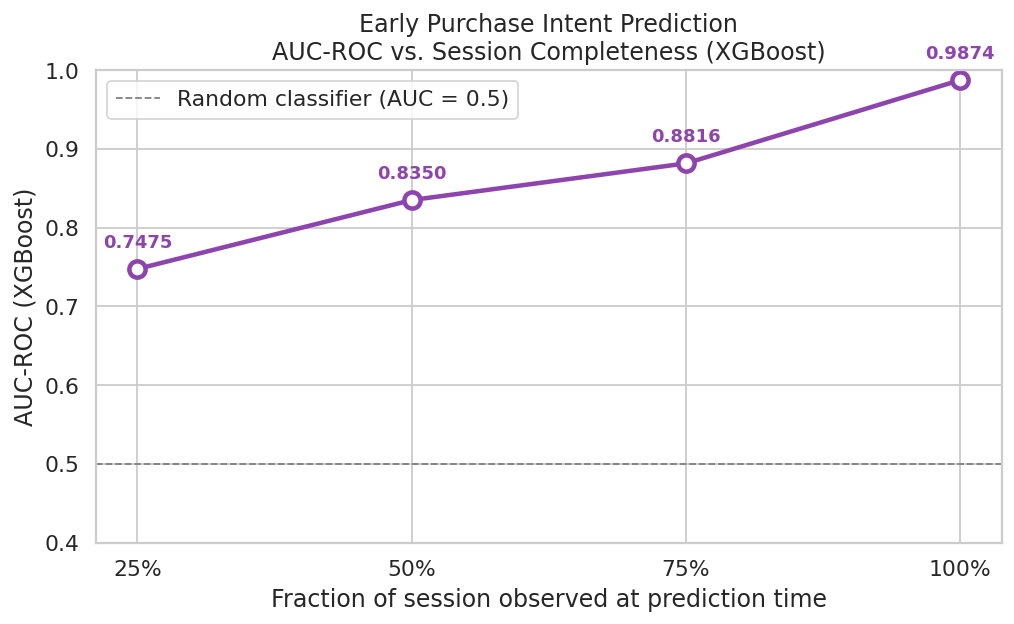

Early prediction figure saved.


In [ ]:
# ── Early prediction plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x_vals = [0.25, 0.50, 0.75, 1.00]
y_vals = [r['AUC-ROC'] for r in early_results]

ax.plot(x_vals, y_vals, 'o-', color='#8e44ad', linewidth=2.5,
        markersize=9, markerfacecolor='white', markeredgewidth=2.5)

# Annotate each point
for x, y in zip(x_vals, y_vals):
    ax.annotate(f'{y:.4f}', xy=(x, y),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='#8e44ad')

ax.axhline(0.5, linestyle='--', color='gray', linewidth=1, label='Random classifier (AUC = 0.5)')
ax.set_xticks(x_vals)
ax.set_xticklabels(['25%', '50%', '75%', '100%'])
ax.set_xlabel('Fraction of session observed at prediction time')
ax.set_ylabel('AUC-ROC (XGBoost)')
ax.set_title('Early Purchase Intent Prediction\nAUC-ROC vs. Session Completeness (XGBoost)')
ax.set_ylim([0.4, min(1.0, max(y_vals) + 0.1)])
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_early_prediction.png', dpi=150)
plt.show()
print('Early prediction figure saved.')

## Final Results Summary

In [ ]:

# ── Full model comparison table ───────────────────────────────────────────────
results_df = pd.DataFrame(results_table)

results_df = pd.concat([
    results_df,
    pd.DataFrame([
        {
            'Model'        : 'Requena et al. (2020) — XGBoost baseline',
            'AUC-ROC'      : 0.8817,
            'Avg Precision': 'Not Reported',
            'F1'           : 0.8808,
            'Precision'    : 'Not Reported',
            'Recall'       : 'Not Reported',
        }
    ])
], ignore_index=True)

print('\n' + '='*70)
print('FINAL MODEL COMPARISON TABLE')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)


FINAL MODEL COMPARISON TABLE
                                   Model  AUC-ROC Avg Precision     F1    Precision       Recall
                     Logistic Regression   0.9733        0.2767 0.3902       0.2425       0.9989
                           Random Forest   0.9706        0.6301 0.5290       0.6697       0.4372
                                 XGBoost   0.9874        0.6304 0.4263       0.2729        0.974
Requena et al. (2020) — XGBoost baseline   0.8817  Not Reported 0.8808 Not Reported Not Reported


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/thesiscode.ipynb" /content/

In [ ]:
!jupyter nbconvert --to html /content/thesiscode.ipynb

[NbConvertApp] Converting notebook /content/thesiscode.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 1598344 bytes to /content/thesiscode.html


In [ ]:
from google.colab import files
files.download("/content/thesiscode.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>